In [ ]:
import numpy as np
import pandas as pd
import scipy

from scipy import signal

# Data Smoothing

Real data are often noisy. Real data are often oversampled. In either case, it is sometimes advisable to smooth the data before analysis. At the very least, smoothing the data gives you a better idea of what is really in the data.

## The data smoothing process is known to be useful in helping with the identification of trends in the data.
For example, the astronomical data are usually binned rather than continuous, that is, each event can be placed in a discrete bin. For example, a photon detected by a CCD detector falls in a particular pixel on the detector, with integral values of X and Y coordinates, or a flux is measured during a particular readout of the detector, which falls within a discrete time interval.

There are a number of ways to smooth the data:


- ## Coaddition and Histogram:
This is particularly useful when the data are oversampled. Merely add together adjacent bins. Add the errors in quadrature. This will decrease the number of pixels, increase the number of counts, and improve the S/N in each pixel. But beware: if you coadd too many pixels you could lose resolution.

The improvement in signal to noise ratio as a process of co-addition is demonstrated below in the case of the detection of a gamma ray burst (which is an astrophysical transient event which happens for a small duration of time).

Filename: /Users/shabnam/Desktop/glg_tte_n7_bn160821937_v00.fit
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      37   ()      
  1  EBOUNDS       1 BinTableHDU     58   128R x 3C   [1I, 1E, 1E]   
  2  EVENTS        1 BinTableHDU     48   576310R x 2C   [1D, 1I]   
  3  GTI           1 BinTableHDU     44   1R x 2C   [1D, 1D]   
ColDefs(
    name = 'CHANNEL'; format = '1I'; unit = 'none'
    name = 'E_MIN'; format = '1E'; unit = 'keV'
    name = 'E_MAX'; format = '1E'; unit = 'keV'
)


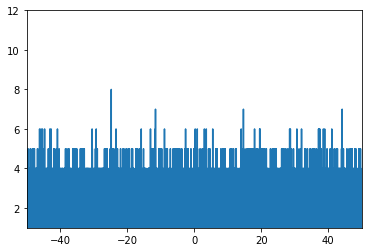

In [ ]:
from astropy.io import fits
from numpy import arange
Swift_met_in_Fermi = 493511357.303
#Event file name  ############Detector N7###########
event_filename ='/Users/shabnam/Desktop/glg_tte_n7_bn160821937_v00.fit'
#event_filename ='/Users/shabuiyyani/sGRB_Data/Fermi_sGRB_data/bn160821937/glg_tte_n7_bn160821937_v00.fit'

#Open the fits file
pha_list = fits.open(event_filename, memmap=True)


#Get info of the fits file
pha_list.info()

#Print the columns of the header Q0
print(pha_list[1].columns)

# load the data in separate variable
pha_data1 = pha_list[1].data

#Energy channel number
#Energy_channel = pha_data1['CHANNEL']

#load the data in separate variable events
pha_data2 = pha_list[2].data

#PHA
PHA =pha_data2['PHA']

#Time
Time = pha_data2['TIME']

#Sort time with respect to the triggertime
Trigger_time = Swift_met_in_Fermi # Swift trigger time in Fermi #Trigger_time =493511357.333 This is the actual Fermi trigger time
T_n7 = Time - Trigger_time

#Creating dictionary for Time
d_n7 = {T_n7[n]: n for n in range(len(T_n7))}

#Defining the good time interval
Time_lc=[]

#removing all the values below 100 s before and after the trigger time in the T array and storing the corresponding energy values

for key in d_n7:
    if key > -100 and key < 244:
        Time_lc.append(key)


# Bin width
binwidth = 0.001  #sec

#Bins info
bins =arange(int(min(Time_lc)),int(max(Time_lc)) + binwidth, binwidth)
#Nbins =len(bins)

#Histogram of events times
counts_n7, edges=np.histogram(Time_lc,bins)

Tav_n7 =[]
for i in range(len(edges)-1):
    Tav_n7.append((edges[i] + edges[i+1])/2)

import matplotlib.pyplot as plt
plt.figure()
plt.step(Tav_n7,counts_n7,where='mid')
plt.ylim([1,12])
plt.xlim([-50,50])
plt.show()

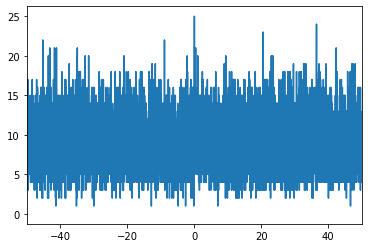

In [ ]:
#Bin width
binwidth = 0.01  #sec

#Bins info
bins =arange(int(min(Time_lc)),int(max(Time_lc)) + binwidth, binwidth)
#Nbins =len(bins)

#Histogram of events times
counts_n7, edges=np.histogram(Time_lc,bins)

Tav_n7 =[]
for i in range(len(edges)-1):
    Tav_n7.append((edges[i] + edges[i+1])/2)

import matplotlib.pyplot as plt
plt.figure()
plt.step(Tav_n7,counts_n7,where='mid')
plt.xlim([-50,50])
plt.show()

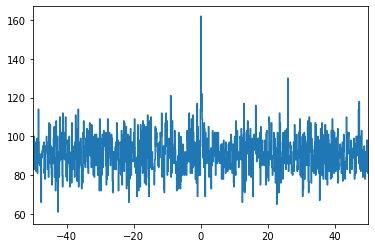

In [ ]:
#Bin width
binwidth = 0.1  #sec

#Bins info
bins =arange(int(min(Time_lc)),int(max(Time_lc)) + binwidth, binwidth)
#Nbins =len(bins)

#Histogram of events times
counts_n7, edges=np.histogram(Time_lc,bins)

Tav_n7 =[]
for i in range(len(edges)-1):
    Tav_n7.append((edges[i] + edges[i+1])/2)

import matplotlib.pyplot as plt
plt.figure()
plt.step(Tav_n7,counts_n7,where='mid')
plt.xlim([-50,50])
plt.show()

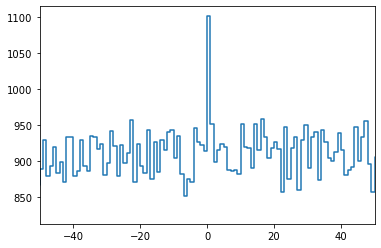

In [ ]:
#Bin width
binwidth = 1.0 #sec

#Bins info
bins =arange(int(min(Time_lc)),int(max(Time_lc)) + binwidth, binwidth)
#Nbins =len(bins)

#Histogram of events times
counts_n7, edges=np.histogram(Time_lc,bins)

Tav_n7 =[]
for i in range(len(edges)-1):
    Tav_n7.append((edges[i] + edges[i+1])/2)

import matplotlib.pyplot as plt
plt.figure()
plt.step(Tav_n7,counts_n7,where='mid')
plt.xlim([-50,50])
plt.show()

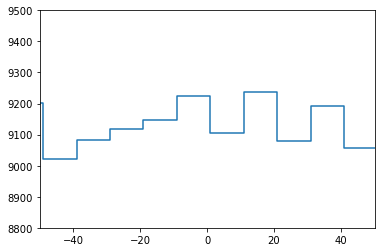

In [ ]:
#Bin width
binwidth = 10.0 #sec

#Bins info
bins =arange(int(min(Time_lc)),int(max(Time_lc)) + binwidth, binwidth)
#Nbins =len(bins)

#Histogram of events times
counts_n7, edges=np.histogram(Time_lc,bins)

Tav_n7 =[]
for i in range(len(edges)-1):
    Tav_n7.append((edges[i] + edges[i+1])/2)

import matplotlib.pyplot as plt
plt.figure()
plt.step(Tav_n7,counts_n7,where='mid')
plt.xlim([-50,50])
plt.ylim([8800,9500])
plt.show()

- ## Running Mean, or Boxcar Smoothing:
  
## 1. Pixel Replacement with Mean of N Pixels:

This describes a smoothing process where each pixel in an image is replaced by the average of $N$ neighboring pixels.
The number of pixels in the image remains the same because no pixels are removed; only their values are modified.

Assuming that the noise is random and uncorrelated between neighboring pixels, averaging $N$ pixels reduces the noise by a factor of
$\sqrt{N}$ while the signal remains roughly unchanged.
This follows from statistical properties: if independent noise values with standard deviation $\sigma$ are averaged, the new standard deviation becomes $\sigma/\sqrt{N}$ leading to an increase in S/N by $\sqrt{N}$.

**Boxcar smoothing** is a specific type of smoothing where a fixed-size kernel (usually a square or rectangular window) is used to take the average of pixels. Boxcar smoothing, however, reduces the resolution as the information is lost.  

Otherwise, within the size of the box which contains a fixed number of points, the average of the data points lying within this box is considered. As shown below in the figure. As evident, this results in smoothing, however, also loses information. This loss of resolution in an image occurs because small-scale variations (fine details) are smoothed out.

![Screenshot%202023-10-16%20at%208.22.31%20PM.png](attachment:Screenshot%202023-10-16%20at%208.22.31%20PM.png)

In a **Simple moving average**, the window size, N, remains contant, where the current datapoint is at the centre and you step the window at a certain chosen width.

Another type is the **cumulative moving average**, where the window size keeps increasing as it calculates the average of all the datapoints until the current datapoint.

- ## Convolution:
The running mean (above) is the convolution of the data with a step function of width N pixels. It is possible, and often advantageous, to smooth by convolving the data with other functions. Convolving with a triangle or a Gaussian places more weight on the central pixel, and preserves the resolution better, than does smoothing with a boxcar (but the S/N is lower for the same width). Convolution with fancier functions can be also be used depending on the requirements.

# Density Estimation

A simple estimator, very commonly used in astronomy, is the histogram, a plot of counts in grouped (or binned) data.
The density in a histogram is given by
# \begin{equation*}
f(x) = \frac{n(x)}{N h(x)}
\end{equation*}

### where 'n' is the number of counts in the i th bin, N is the total data (or size of the random variable) and h is the width of the bin of the histogram

The critical issue for histograms and other techniques of nonparametric density estimation is the choice of bin width h.

### It is a tradeoff between bias and variance.
The analysis of the bias tells us that the more bins we are using, the less bias the
histogram has. This makes sense because when we have many bins, we have a higher resolution so we can
approximate the fine density structure better.

The analysis of the variance has an interesting result: the more bins we are using, the higher variance we
are suffering.

An interesting feature of the histogram is that: we can choose, M, the number of bins. When M is too large,
the first quantity (bias) will be small while the second quantity (variance) will be large; this case is called
**undersmoothing**. When M is too small, the first quantity (bias) is large but the second quantity (variance)
is small; this case is called **oversmoothing**.

To balance the bias and variance, we choose the number of bins that minimizes the sum of bias and variance.

If the random variable has a normal distribution, then simple thumb rule for deciding on the bin width h is given by
(Scott 1979)
# \begin{equation*}
h(x) = \frac{2 IQR}{N^{1/3}}
\end{equation*}

where IQR is the inter quartile range.

For multi-variate dataset with p dimensions:
# \begin{equation*}
h(x) = \frac{2 IQR}{N^{1/(2+p)}}
\end{equation*}



### A major problem with histograms, however, is that the choice of binning can have a disproportionate effect on the resulting visualization.

Practical rule of selecting M is related to the problem of bandwidth selection, a research topic in statistics.

(https://scikit-learn.org/stable/auto_examples/neighbors/plot_kde_1d.html)

Text(-3.5, 0.31, 'Histogram, bins shifted')

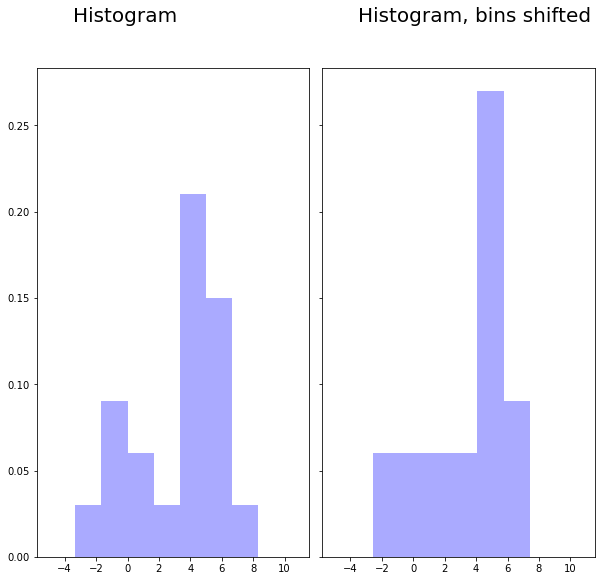

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
N = 20
X = np.concatenate(
    (np.random.normal(0, 1, int(0.3 * N)), np.random.normal(5, 1, int(0.7 * N)))
)[:,np.newaxis]
X_plot = np.linspace(-5, 10, 1000)#[:, np.newaxis]
#print(X_plot)
bins = np.linspace(-5, 10, 10)

# Plot the progression of histograms to kernels

fig, (ax1,ax2) = plt.subplots(1, 2,figsize=(10,9),  sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# histogram 1
ax1.hist(X, bins=bins, fc="#AAAAFF", density=True)
ax1.text(-3.5, 0.31, "Histogram",fontsize=20)

# histogram 2
ax2.hist(X, bins=bins + 0.75, fc="#AAAAFF", density=True)
ax2.text(-3.5, 0.31, "Histogram, bins shifted",fontsize=20)


Intuitively, one can also think of a histogram as a stack of blocks, one block per point. By stacking the blocks in the appropriate grid space, we recover the histogram. But what if, instead of stacking the blocks on a regular grid, we center each block on the point it represents, and sum the total height at each location? This idea leads to the visualization of top hat kernel density plot. It is perhaps not as clean as a histogram, but the fact that the data drive the block locations mean that it is a much better representation of the underlying data.


This visualization is an example of a kernel density estimation, in this case with a top-hat kernel (i.e. a square block at each point). We can recover a smoother distribution by using a smoother kernel. The bottom-right plot shows a Gaussian (standard normal) kernel density estimate, in which each point contributes a Gaussian curve to the total. The result is a smooth density estimate which is derived from the data, and functions as a powerful non-parametric model of the distribution of points.

Let (x1, x2, ..., xn) be independent and identically distributed samples drawn from some univariate distribution with an unknown density, $f$ at any given point $x$. We are interested in estimating the shape of this function ƒ. Its kernel density estimator is given by

# $
f(x) =
\begin{equation*}
\frac{1}{nh} \sum_{i=1}^{n} K \left(\frac{x-x_i}{h}\right)
\end{equation*}
$

### where $K$ is the kernel — a non-negative function — and $h$ > 0 is a smoothing parameter called the bandwidth.

# Kernel

The kernel of a probability density function is the form of the pdf in which any factors that are not functions of any of the variables in the domain are omitted.
For example consider a normal distribution
# $
f(x) =
\begin{equation*}
\frac{1}{\sigma \sqrt{2 \pi}} \exp{(-\frac{x^2}{2\sigma^2})}
\end{equation*}
$

### The associated kernel is


# \begin{equation*}
K \propto \exp{(-\frac{x^2}{2\sigma^2})}
\end{equation*}

### Additional properties:

###  - Normalization:
## \begin{equation*}
\int _{-\infty }^{+\infty }K(x)\,dx=1
\end{equation*}

### - Symmetry:
## \begin{equation*}
K(-x)=K(x){\mbox{ for all values of }}x
\end{equation*}

[[0.]]


Text(0.5, 1.0, 'Available Kernels')

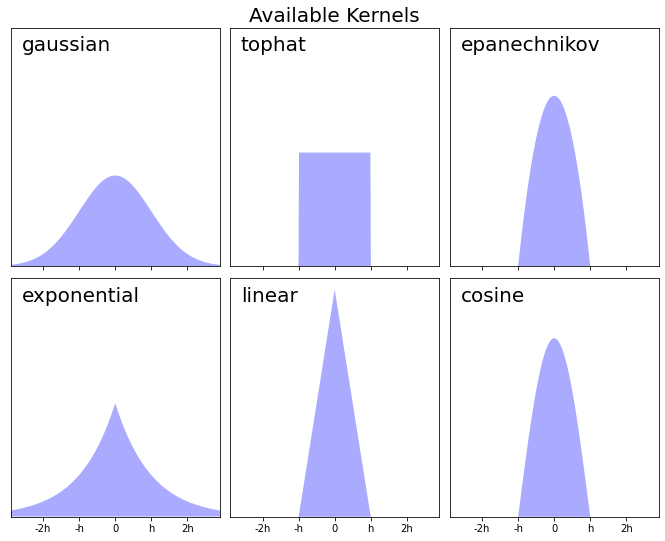

In [ ]:
from scipy.stats import norm
from sklearn.neighbors import KernelDensity
# ----------------------------------------------------------------------
# Plot all available kernels
X_plot = np.linspace(-6, 6, 1000)[:, None]
X_src = np.zeros((1, 1))
print(X_src)

fig, ax = plt.subplots(2, 3, figsize=(10,9), sharex=True, sharey=True)
fig.subplots_adjust(left=0.05, right=0.95, hspace=0.05, wspace=0.05)


def format_func(x, loc):
    if x == 0:
        return "0"
    elif x == 1:
        return "h"
    elif x == -1:
        return "-h"
    else:
        return "%ih" % x


for i, kernel in enumerate(
    ["gaussian", "tophat", "epanechnikov", "exponential", "linear", "cosine"]
):
    axi = ax.ravel()[i]

    log_dens = KernelDensity(kernel=kernel).fit(X_src).score_samples(X_plot)

    axi.fill(X_plot[:,0], np.exp(log_dens), "-k", fc="#AAAAFF")
    axi.text(-2.6, 0.95, kernel,fontsize=20)

    axi.xaxis.set_major_formatter(plt.FuncFormatter(format_func))
    axi.xaxis.set_major_locator(plt.MultipleLocator(1))
    axi.yaxis.set_major_locator(plt.NullLocator())

    axi.set_ylim(0, 1.05)
    axi.set_xlim(-2.9, 2.9)

ax[0, 1].set_title("Available Kernels",fontsize=20)

### Bandwidth, h

The bandwidth of the kernel is a free parameter which exhibits a strong influence on the resulting estimate.

![Screenshot%202022-10-24%20at%2010.18.50%20PM.png](attachment:Screenshot%202022-10-24%20at%2010.18.50%20PM.png)
(https://en.wikipedia.org/wiki/Kernel_density_estimation#:~:text=Its%20kernel%20density%20estimator%20is,K(x%2Fh).)


The above figure example is using a dataset of 100 data sampled from a normal distribution (shown in grey). The red shows an undersmoothed kernel density estimater for h = 0.05; green shown the scenario where the kernel density estimator is oversmoothed where h=2 (in such a case it approaches the shape of the kernel used, here it is gaussian, centred around the mean of the dataset). In a scenario where h = 0 (i.e no smoothing), the kernel density estimate is a sum of n delta functions centered at the coordinates of analyzed samples (shown in blue vertical lines). The black curve with a bandwidth of h = 0.337 is considered to be optimally smoothed since its density estimate is close to the true density.

**Larger $\it h$ values lead to wider, smoother density estimates-can lead to oversmoothing**

**Smaller $\it h$ values result in narrower, more localized kernels, capturing finer details in the data-can lead to undersmoothing**

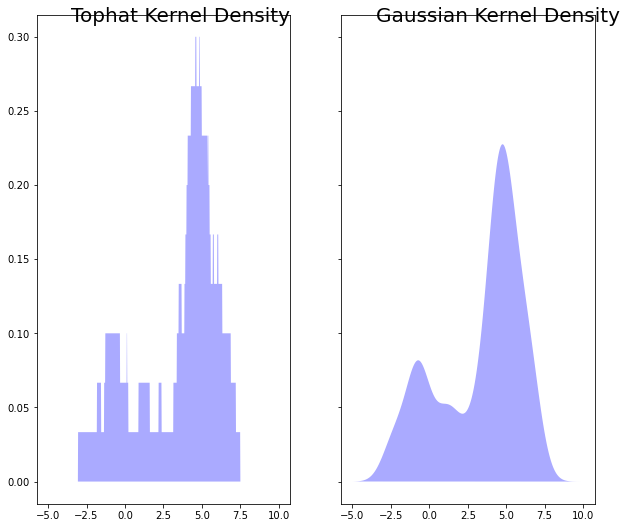

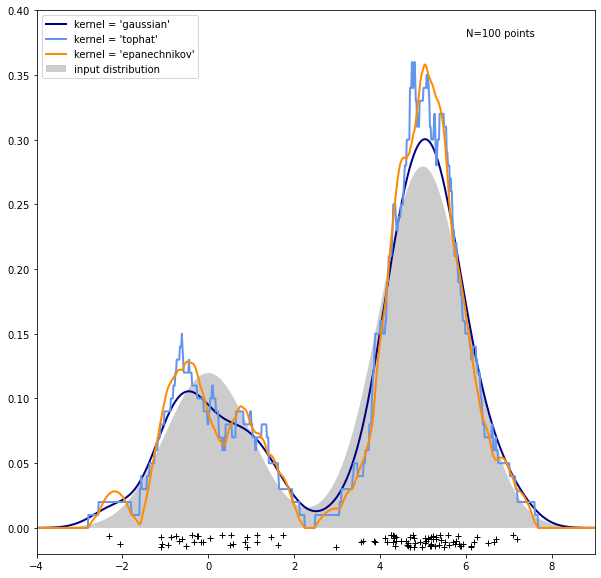

In [ ]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(10,9), sharex=True, sharey=True)
# tophat KDE
X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]
kde = KernelDensity(kernel="tophat", bandwidth=0.75).fit(X) #Fit the Kernel Density model on the data.
log_dens = kde.score_samples(X_plot) #Compute the log-likelihood of each sample under the model.
ax1.fill(X_plot[:, 0], np.exp(log_dens), fc="#AAAAFF")
ax1.text(-3.5, 0.31, "Tophat Kernel Density",fontsize=20)

# Gaussian KDE
kde = KernelDensity(kernel="gaussian", bandwidth=0.75).fit(X)
log_dens = kde.score_samples(X_plot)
ax2.fill(X_plot[:, 0], np.exp(log_dens), fc="#AAAAFF")
ax2.text(-3.5, 0.31, "Gaussian Kernel Density",fontsize=20)

# for axi in ax.ravel():
#     axi.plot(X[:, 0], np.full(X.shape[0], -0.01), "+k")
#     axi.set_xlim(-4, 9)
#     axi.set_ylim(-0.02, 0.34)

# for axi in ax[:, 0]:
#     axi.set_ylabel("Normalized Density")

# for axi in ax[1, :]:
#     axi.set_xlabel("x")



# ----------------------------------------------------------------------
# Plot a 1D density example
N = 100
np.random.seed(1)
X = np.concatenate(
    (np.random.normal(0, 1, int(0.3 * N)), np.random.normal(5, 1, int(0.7 * N)))
)[:, np.newaxis]

X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]

true_dens = 0.3 * norm(0, 1).pdf(X_plot[:, 0]) + 0.7 * norm(5, 1).pdf(X_plot[:, 0])

fig, ax = plt.subplots(figsize=(10,10))
ax.fill(X_plot[:, 0], true_dens, fc="black", alpha=0.2, label="input distribution")
colors = ["navy", "cornflowerblue", "darkorange"]
kernels = ["gaussian", "tophat", "epanechnikov"]
lw = 2

for color, kernel in zip(colors, kernels):
    kde = KernelDensity(kernel=kernel, bandwidth=0.5).fit(X)
    log_dens = kde.score_samples(X_plot)
    ax.plot(
        X_plot[:, 0],
        np.exp(log_dens),
        color=color,
        lw=lw,
        linestyle="-",
        label="kernel = '{0}'".format(kernel),
    )

ax.text(6, 0.38, "N={0} points".format(N))

ax.legend(loc="upper left")
ax.plot(X[:, 0], -0.005 - 0.01 * np.random.random(X.shape[0]), "+k")

ax.set_xlim(-4, 9)
ax.set_ylim(-0.02, 0.4)
plt.show()

- ## Fourier Smoothing:
Real data is often affected by 1/f noise (pink noise), or high frequency (pixel-to-pixel) noise (white noise). Low frequency (slowly-varying) noise does not greatly affect small features in an image (stars, or narrow spectral lines).

1/f noise affects long-term trends (e.g., slow drifts in astronomical measurements, stock markets etc).
High-frequency noise affects sharp details (e.g., pixel noise in images).

By working in the frequency domain, you can preferentially filter out particular frequencies.

### Steps in Fourier Smoothing:
- Generate a noisy signal (e.g. sine wave with added random noise).

- Apply the Fourier Transform (FFT) to convert it to the frequency domain.

- Filter out high-frequency components (low-pass filter) or any particular preferred frequency

- Apply the Inverse Fourier Transform (IFFT) to get the smoothed signal.

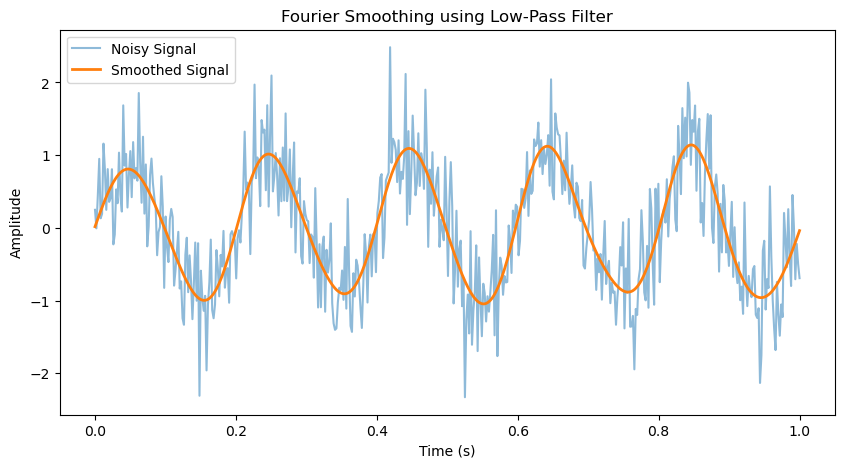

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a noisy signal
np.random.seed(42)
t = np.linspace(0, 1, 500)  # Time vector
signal = np.sin(2 * np.pi * 5 * t)  # Sine wave (5 Hz)
noise = 0.5 * np.random.randn(len(t))  # Add Gaussian noise
noisy_signal = signal + noise

# Apply Fourier Transform
fft_signal = np.fft.fft(noisy_signal)
frequencies = np.fft.fftfreq(len(t), d=t[1] - t[0])  # Frequency values

# Apply Low-Pass Filter (keep only low frequencies)
cutoff = 10  # Cutoff frequency (in Hz)
fft_signal[np.abs(frequencies) > cutoff] = 0  # Remove high frequencies

# Inverse Fourier Transform to get the smoothed signal
smoothed_signal = np.fft.ifft(fft_signal)

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(t, noisy_signal, label="Noisy Signal", alpha=0.5)
plt.plot(t, smoothed_signal.real, label="Smoothed Signal", linewidth=2)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Fourier Smoothing using Low-Pass Filter")
plt.show()

# Time Domain Smoothing Filter
## Apply a Savitzky-Golay filter to an array.

The Savitzky-Golay filter removes high frequency noise from data. It has the advantage of preserving the original shape and features of the signal better than other types of filtering approaches, such as moving averages techniques.

The main idea behind this approach is to make for each point a least-square fit with a polynomial of high order over a odd-sized window centered at the point.

### How It Works:
- Choose a window size (must be odd): This determines how many neighboring points contribute to the fit.

- Select a polynomial order: A higher-order polynomial allows capturing more variations in the data, but can lead to overfitting.

- Perform least squares fitting: For each point in the array, a polynomial is fitted to the data in the local window.

- Replace the central point with the value obtained from the polynomial fit.

- The window moves one point at a time (not in steps of window size), ensuring a smooth and continuous filtering process.

### Key rules
- Window Size Must be odd (e.g., 5, 7, 11, …)
- It must be greater than polynomial order
- Controls degree of smoothing
- Choose a polynomial order which is less than the window size.

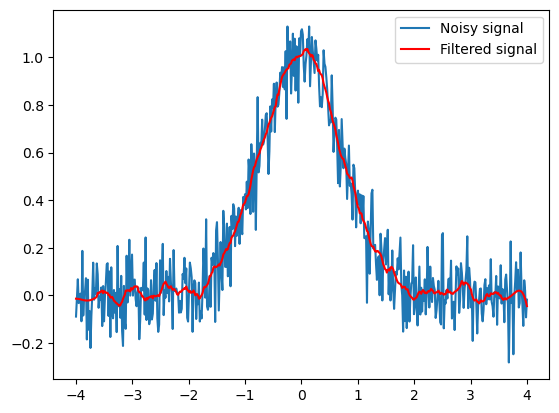

In [ ]:
import numpy as np
t = np.linspace(-4, 4, 500)
y = np.exp( -t**2 ) + np.random.normal(0, 0.1, t.shape)
from scipy.signal import savgol_filter
ysg = savgol_filter(y, window_length=45, polyorder=4)
import matplotlib.pyplot as plt
plt.plot(t, y, label='Noisy signal')
#plt.plot(t, np.exp(-t**2), 'k', lw=1.5, label='Original signal')
plt.plot(t, ysg, 'r', label='Filtered signal')
plt.legend()
plt.show()

/var/folders/1s/qv77bg195jj73d1b1tvlj5140000gn/T/ipykernel_51639/2989816721.py:11: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  ax2.locator_params(axis='x', nbins=5)


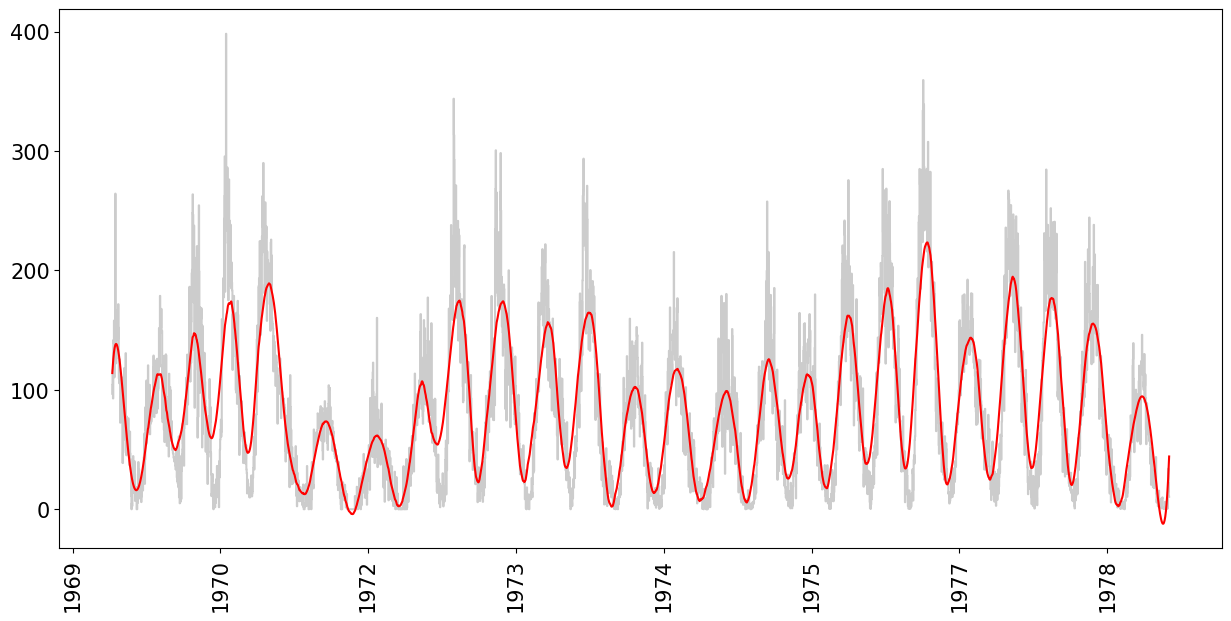

In [ ]:
import pandas as pd
df_sun = pd.read_csv('/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132_6132_Statistical_and_data_analysis_in_Physical_Sciences/Statistics_Modules/DataSets/Sunspots.csv')

Time =df_sun['Date']
sunspot = df_sun['Monthly_Mean_Total_Sunspot_Number']

import matplotlib.pyplot as plt
#Light curve plot
fig_sun, ax2 = plt.subplots(figsize=(15,7))
ax2.step(Time,sunspot, 'k',alpha=0.2)
ax2.locator_params(axis='x', nbins=5)
ysg = savgol_filter(sunspot, window_length=201, polyorder=5)
ax2.plot(Time, ysg, 'r', label='Filtered signal')


import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
import matplotlib.dates as mdates

dtFmt = mdates.DateFormatter('%Y') # define the formatting
plt.gca().xaxis.set_major_formatter(dtFmt)
# show every 12th tick on x axes
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=15))
plt.xticks(rotation=90, fontweight='light',  fontsize='x-small',)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
plt.show()